# RQ1 — Data Quality Characteristics (Q9–Q16)

**Analysis to Address RQ1**: Q9–Q16 — word associations, RE experience, importance/priority of 13 data quality characteristics, justifications, trade-offs, and data version control.

Statistical methods: diverging stacked bars with 95% CI, paired Wilcoxon signed-rank (importance vs priority), Friedman + Nemenyi post-hoc (global ranking).

### imports

In [51]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

sys.path.insert(0, str(Path.cwd()))
import utils as U

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"
TABLES.mkdir(exist_ok=True)

df = U.load_anonymized()
imp_long = pd.read_csv(U.DATA_PROC / "likert_importance.csv")
pri_long = pd.read_csv(U.DATA_PROC / "likert_priority.csv")
skills_long = pd.read_csv(U.DATA_PROC / "skills.csv")
words_long = pd.read_csv(U.DATA_PROC / "words.csv")
print(f"N={len(df)}, importance={len(imp_long)}, priority={len(pri_long)}, tokens Q9={len(words_long)}")


N=56, importance=728, priority=728, tokens Q9=279


Q9 — Top Mind 5 Words

In [52]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('').resolve()))
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import utils as U

In [53]:
DATA = pathlib.Path('..') / 'data' / 'raw'
df_raw = pd.read_excel(DATA / 'full_quali.xlsx')

word_cols = ['word_1', 'word_2', 'word_3', 'word_4', 'word_5']

# Flatten → unique words (lowercase)
words_flat = (
    df_raw[word_cols]
    .stack()
    .str.lower()
    .str.strip()
    .dropna()
)
unique_words = sorted(words_flat.unique())
print(f'Total tokens: {len(words_flat)}  |  Unique: {len(unique_words)}')
print(unique_words[0:])


Total tokens: 278  |  Unique: 151
['-', 'abundant', 'accessibility', 'accordance', 'accuracy', 'afirmative', 'amount', 'analysis', 'anotation', 'anova', 'approximation', 'autorization', 'availability', 'avaliation', 'balance', 'balancing', 'bias', 'business', 'cheap', 'clarity', 'cleaning', 'coherence', 'cohesion', 'collect', 'completeness', 'compliance', 'comprehensibility', 'comprehensiblity', 'consistency', 'correctness', 'credibility', 'current', 'data bank', 'data_analysis', 'data_dependency', 'data_freshness', 'data_recency', 'data_streaming', 'dataleakage', 'dataset', 'deduplication', 'desbalancing', 'descriptive', 'determination', 'distinction', 'distribution', 'diversity', 'eda', 'effectiveness', 'efficiency', 'encoder', 'especialists', 'essential', 'expensive', 'explainability', 'filters', 'format', 'formatted', 'foundation', 'granularity', 'identifiable', 'iid', 'important', 'incompleteness', 'inconsistency', 'incorrect_labels', 'indefined', 'indispensable', 'information', '

values '-', read_me removed

normalizations made  
(8) Null data → missingness  
(9) Complete data → completeness  
(9) enouth data → sufficiency  
(8) Old data → data_recency  
(3) Data dependency → data_dependency  
(4) Dados atuais → data_freshness  
(8) Data streaming → data streaming  
(9) no duplication → deduplication  
(14) incorrect labels → incorrect_labels  
(7) data analysis → data_analysis  
(9) real data → real  

In [54]:
groups = {
    "quality": ["quality", "qualified", "reliability", "reliable", "reliablity",
                "credibility", "correctness", "accuracy", "precision"],
    "completeness": ["completeness", "incompleteness", "missing",
                     "null", "nullity", "abundant",
                     "missingness", "sufficiency"],
    "consistency": ["consistency", "inconsistency", "coherence", "cohesion",
                    "stability", "symmetry", "balance"],
    "volume": ["volume", "quantity", "amount", "scale"],
    "representativeness": ["representativeness", "diversity", "distribution", "iid",
                           "desbalancing", "balancing", "bias"],
    "noise": ["noise", "outlier", "outliers", "outliners", "signal"],
    "freshness": ["current", "old", "update", "time",
                  "data_recency", "data_freshness", "data streaming", "real"],
    "provenance": ["provenance", "origin", "source", "traceability", "rastreabilidade",
                   "foundation"],
    "clarity": ["clarity", "comprehensibility", "comprehensiblity", "explainability",
                "transparency", "anotation", "read_me", "descriptive"],
    "compliance": ["compliance", "accordance", "autorization", "security",
                   "identifiable", "afirmative"],
    "accessibility": ["accessibility", "availability", "use", "reuse"],
    "integrity": ["integrity", "keys", "deduplication", "data_dependency",
                  "multicollinearity", "relation"],
    "structure": ["structure", "organization", "organisation", "format", "formatted",
                  "standard", "standardization", "standartise", "granularity",
                  "type", "term"],
    "processing": ["processing", "cleaning", "sanitize", "normalization", "transformed",
                   "encoder", "filters", "split", "tractate"],
    "analysis": ["data_analysis", "eda", "anova", "regression",
                 "approximation", "variance", "measurement", "determination",
                 "distinction"],
    "visualization": ["visualisation", "plotting"],
    "performance": ["performance", "performace", "efficiency", "effectiveness",
                    "otimization", "scalability"],
    "cost": ["cheap", "expensive", "investiment", "time-consuming"],
    "pipeline": ["pipeline", "collect", "integration", "dataset", "data bank",
                 "training", "test", "result"],
    "validation": ["validation", "validate", "validade", "verify", "avaliation",
                   "dataleakage"],
    "relevance": ["relevance", "important", "essential", "necessary", "indispensable",
                  "neglected", "value", "information"],
    "expertise": ["especialists", "interdisciplinarity", "subjectivity", "business",
                  "technique", "requisit"],
    "transferability": ["transferability"],
    "invalid": ["incorrect_labels", "indefined"],
}

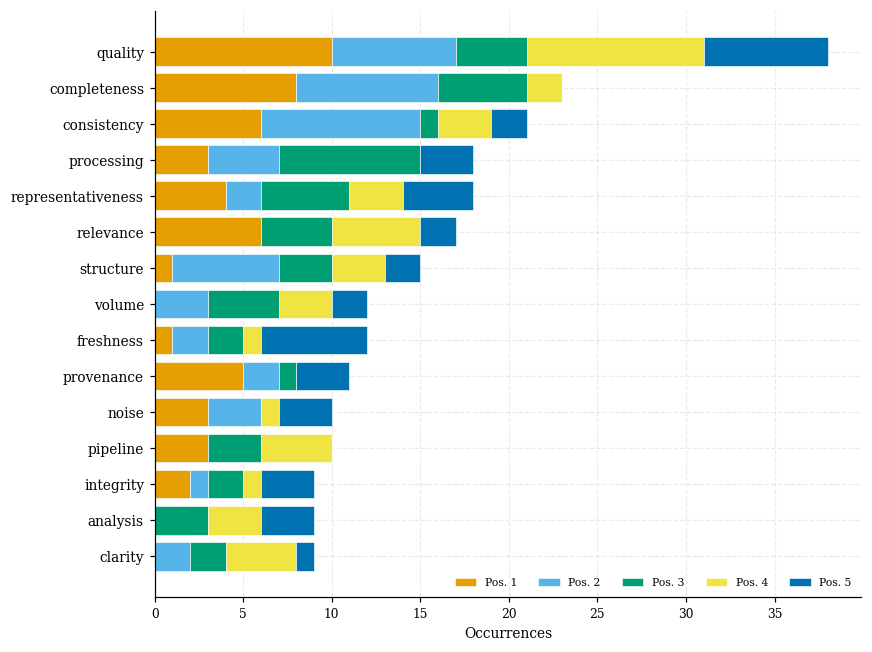

In [55]:
word_to_label = {w: label for label, words in groups.items() for w in words}

word_pos = (
    df_raw[word_cols]
    .stack()
    .str.lower()
    .str.strip()
    .dropna()
    .reset_index()
)
word_pos.columns = ['resp_idx', 'word_col', 'word']
word_pos['position'] = word_pos['word_col'].str.extract(r'(\d+)').astype(int)

word_pos['label'] = word_pos['word'].map(word_to_label).fillna('unknown')

agg = (
    word_pos.groupby(['label', 'position'])
    .size()
    .unstack(fill_value=0)
)
pos_cols = sorted(agg.columns)

agg = agg.loc[agg.sum(axis=1).sort_values(ascending=False).head(15).index]

agg = agg.iloc[::-1]

try:
    colors = U.PALETTE_WONG[1 : len(pos_cols) + 1]
except Exception:
    colors = plt.cm.tab10.colors[: len(pos_cols)]

fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(agg))
bottom = np.zeros(len(agg))

for i, pos in enumerate(pos_cols):
    width = agg[pos].values
    ax.barh(y, width, left=bottom,
            color=colors[i % len(colors)],
            edgecolor='white', linewidth=0.4,
            label=f'Pos. {pos}')
    bottom += width

ax.set_yticks(y)
ax.set_yticklabels(agg.index, fontsize=9)
ax.set_xlabel('Occurrences')
ax.legend(loc='lower right', frameon=False,
          ncol=len(pos_cols), fontsize=7)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

pathlib.Path('../figures').mkdir(exist_ok=True)
plt.savefig('../figures/q9_top_mind_words.pdf', dpi=150, bbox_inches='tight')
plt.show()

In [56]:
_CANDIDATE_COLS = ["canonical", "word", "palavra", "term", "token", "label"]
_WORD_COL = next((c for c in _CANDIDATE_COLS if c in words_long.columns), None)

if _WORD_COL is None:
    raise ValueError(
        f"Nenhuma coluna de palavras encontrada em words_long. "
        f"Colunas disponíveis: {list(words_long.columns)}"
    )

# ---------------------------------------------------------------------------
# Normalização PT → EN
# ---------------------------------------------------------------------------
WORD_PT_TO_KEY: dict[str, str] = {
    "consistência":         "consistency",
    "consistencia":         "consistency",
    "completude":           "completeness",
    "confiabilidade":       "reliability",
    "precisão":             "precision",
    "precisao":             "precision",
    "balanceamento":        "balance",
    "quantidade":           "quantity",
    "atualização":          "currentness",
    "atualizacao":          "currentness",
    "outliers":             "outliers",
    "integração":           "integration",
    "integracao":           "integration",
    "normalização":         "normalization",
    "normalizacao":         "normalization",
    "relevância":           "relevance",
    "relevancia":           "relevance",
    "acurácia":             "accuracy",
    "acuracia":             "accuracy",
    "distribuição":         "distribution",
    "distribuicao":         "distribution",
    "acessibilidade":       "accessibility",
    "qualidade":            "quality",
    "qualidade de dados":   "data quality",
    "confiança":            "reliability",
    "confianca":            "reliability",
    "validade":             "validity",
    "validação":            "validation",
    "validacao":            "validation",
    "integridade":          "integrity",
    "rastreabilidade":      "traceability",
    "disponibilidade":      "availability",
    "segurança":            "security",
    "seguranca":            "security",
    "privacidade":          "privacy",
    "conformidade":         "compliance",
    "processamento":        "processing",
    "pipeline":             "pipeline",
    "estrutura":            "structure",
    "volume":               "volume",
    "frescor":              "freshness",
    "atualidade":           "currentness",
    "ruído":                "noise",
    "ruido":                "noise",
    "análise":              "analysis",
    "analise":              "analysis",
    "representatividade":   "representativeness",
    "proveniência":         "provenance",
    "proveniencia":         "provenance",
    "origem":               "provenance",
    "clareza":              "clarity",
    "compreensibilidade":   "understandability",
    "eficiência":           "efficiency",
    "eficiencia":           "efficiency",
    "duplicatas":           "duplicates",
    "metadados":            "metadata",
    "documentação":         "documentation",
    "documentacao":         "documentation",
    "governança":           "governance",
    "governanca":           "governance",
    "monitoramento":        "monitoring",
    "auditoria":            "audit",
    "credibilidade":        "credibility",
    "recuperabilidade":     "recoverability",
    "sigilo":               "confidentiality",
    "confidencialidade":    "confidentiality",
    "criptografia":         "cryptography",
    "anonimização":         "anonymization",
    "anonimizacao":         "anonymization",
    "consentimento":        "consent",
    "controle":             "control",
    "controle de acesso":   "access control",
    "pessoas":              "people",
    "lgpd":                 "lgpd",
    "proteção":             "protection",
    "protecao":             "protection",
    "padronização":         "standardization",
    "padronizacao":         "standardization",
    "transformação":        "transformation",
    "transformacao":        "transformation",
    "esquema":              "schema",
    "valores ausentes":     "missing values",
    "dados faltantes":      "missing values",
    "nulos":                "null values",
    "valores nulos":        "null values",
    "observabilidade":      "observability",
    "limpeza":              "cleaning"
}

EXTRA_DISPLAY: dict[str, str] = {
    "balance":              "Balance",
    "quantity":             "Quantity",
    "outliers":             "Outliers",
    "integration":          "Integration",
    "normalization":        "Normalization",
    "relevance":            "Relevance",
    "accuracy":             "Accuracy",
    "distribution":         "Distribution",
    "quality":              "Quality",
    "data quality":         "Data Quality",
    "validity":             "Validity",
    "validation":           "Validation",
    "integrity":            "Integrity",
    "security":             "Security",
    "privacy":              "Privacy",
    "processing":           "Processing",
    "pipeline":             "Pipeline",
    "structure":            "Structure",
    "volume":               "Volume",
    "freshness":            "Freshness",
    "noise":                "Noise",
    "analysis":             "Analysis",
    "representativeness":   "Representativeness",
    "provenance":           "Provenance",
    "clarity":              "Clarity",
    "duplicates":           "Duplicates",
    "metadata":             "Metadata",
    "documentation":        "Documentation",
    "governance":           "Governance",
    "monitoring":           "Monitoring",
    "audit":                "Audit",
    "cryptography":         "Cryptography",
    "anonymization":        "Anonymization",
    "consent":              "Consent",
    "control":              "Control",
    "access control":       "Access Control",
    "people":               "People",
    "lgpd":                 "LGPD",
    "confidentiality":      "Confidentiality",
    "protection":           "Protection",
    "standardization":      "Standardization",
    "transformation":       "Transformation",
    "schema":               "Schema",
    "missing values":       "Missing Values",
    "null values":          "Null Values",
    "observability":        "Observability",
}

# U.CHARACTERISTICS_EN tem prioridade (13 características oficiais do paper)
ALL_DISPLAY: dict[str, str] = {**EXTRA_DISPLAY, **U.CHARACTERISTICS_EN}


def normalize_to_en(word: str) -> str:
    """PT word → chave EN curta → label de display oficial."""
    if not isinstance(word, str):
        return word
    w = word.strip().lower()
    key = WORD_PT_TO_KEY.get(w, w)
    return ALL_DISPLAY.get(key, key.capitalize())


# Valores inválidos a descartar (células vazias, traços, placeholders)
_INVALID_VALUES = {"", "-", "--", "n/a", "na", "none", "null", "nan"}


def is_valid_word(word) -> bool:
    """Retorna False para NaN, None, strings vazias ou placeholders."""
    if not isinstance(word, str):
        return False
    return word.strip().lower() not in _INVALID_VALUES


# ---------------------------------------------------------------------------
# Top palavras por posição (top-5 de cada posição)
# ---------------------------------------------------------------------------
TOP_N = 5

words_long_en = words_long.copy()

# Remove linhas com palavras inválidas ANTES de normalizar
words_long_en = words_long_en[words_long_en[_WORD_COL].apply(is_valid_word)].copy()

words_long_en[_WORD_COL] = words_long_en[_WORD_COL].apply(normalize_to_en)

by_pos_full = (
    words_long_en
    .groupby([_WORD_COL, "position"])
    .size()
    .unstack(fill_value=0)
)

positions = [1, 2, 3, 4, 5]
top_words_per_pos = {}
for pos in positions:
    if pos in by_pos_full.columns:
        top_words_per_pos[pos] = by_pos_full[pos].nlargest(TOP_N)

all_top_words = sorted(set(
    w for words in top_words_per_pos.values() for w in words.index
))

cmap = plt.cm.get_cmap('tab20', len(all_top_words))
word_colors = {w: cmap(i) for i, w in enumerate(all_top_words)}

WindowsPath('C:/dev/qualidade-de-dados-em-sistemas-aprendizado-de-maquina/figures/../figures/q9_top_words_by_position.pdf.pdf')

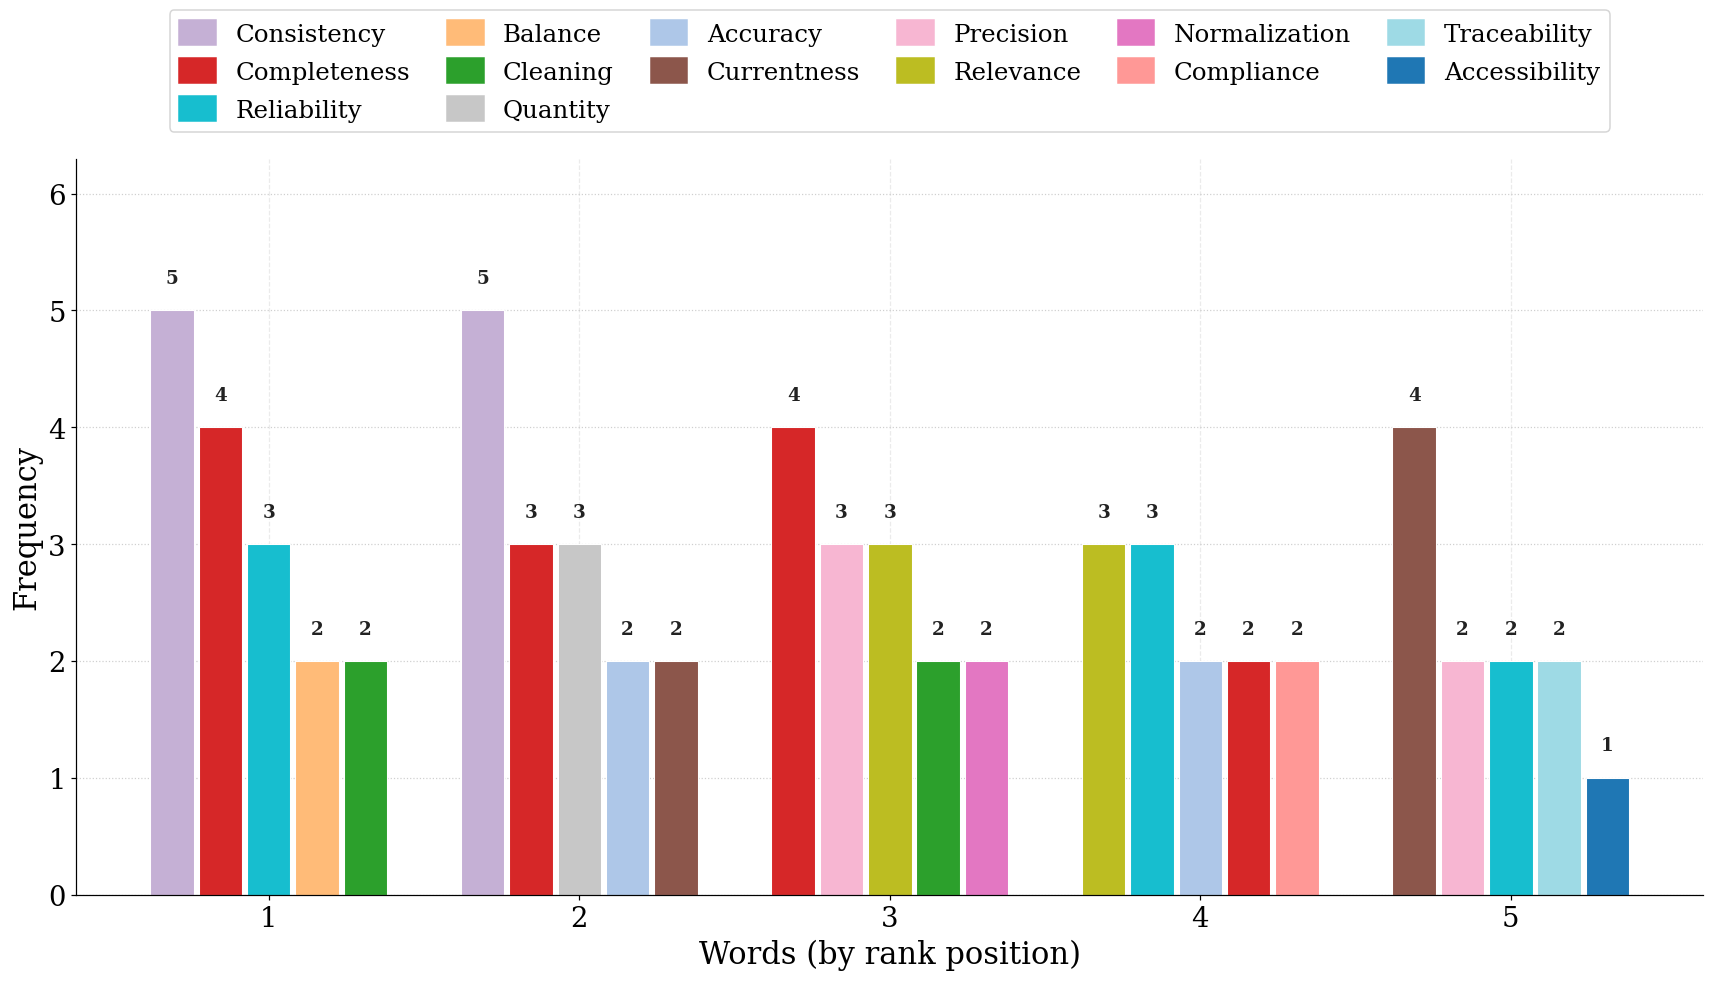

In [ ]:
U.setup_matplotlib()

fig, ax = plt.subplots(figsize=(16, 9))  # ligeiramente maior para suportar fontes grandes

bar_width = 0.07
group_gap = 0.1
legend_handles = {}

for g_idx, pos in enumerate(positions):
    if pos not in top_words_per_pos:
        continue

    words_in_pos = top_words_per_pos[pos]
    group_center = g_idx * (TOP_N * bar_width + group_gap)

    for b_idx, (word, freq) in enumerate(words_in_pos.items()):
        x = group_center + b_idx * bar_width
        color = word_colors[word]

        ax.bar(x, freq, width=bar_width * 0.9,
               color=color, edgecolor='white', linewidth=0.7)

        if word not in legend_handles:
            legend_handles[word] = plt.Rectangle((0, 0), 1, 1, color=color)

        ax.text(x, freq + 0.2, str(int(freq)),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#222222')  # 🔼 fonte maior

group_centers = [
    g * (TOP_N * bar_width + group_gap) + (TOP_N - 1) * bar_width / 2
    for g in range(len(positions))
]

ax.set_xticks(group_centers)
ax.set_xticklabels([str(p) for p in positions], fontsize=18)

ax.set_xlabel("Words (by rank position)", fontsize=20)
ax.set_ylabel("Frequency", fontsize=20)

ax.tick_params(axis='y', labelsize=18)

ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle=':', alpha=0.6)
ax.set_axisbelow(True)
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

# 🔼 legenda no topo e mais próxima
ax.legend(
    legend_handles.values(), legend_handles.keys(),
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),  # 👈 logo acima do gráfico
    ncol=6,
    frameon=True,
    fontsize=16,                # 🔼 maior
    handlelength=1.5,
    handleheight=1.2,
    columnspacing=1.5
)

plt.tight_layout()
U.save_fig(fig, "../figures/q9_top_words_by_position.pdf")

## Q11 — Importance, Priority of Data Quality Characteristics

In [58]:
def _bootstrap_ci(
    long_df: pd.DataFrame,
    item_col: str,
    value_col: str,
    items: list,
    top_levels: list[int],
    bottom_levels: list[int],
    n_bootstrap: int = 1000,
    ci_level: float = 0.95,
    random_state: int | None = 42,
) -> pd.DataFrame:
    """Compute % top/bottom and Bootstrap CI for each item in *items*.

    Parameters
    ----------
    long_df       : long-format DataFrame with columns [item_col, value_col]
    items         : list of keys (values in item_col)
    top_levels    : iterable of Likert values that count as "positive" (e.g. [4, 5])
    bottom_levels : iterable of Likert values that count as "negative" (e.g. [1, 2])
    n_bootstrap   : number of bootstrap resamples (default 1000)
    ci_level      : confidence level, e.g. 0.95 for 95% CI (default 0.95)
    random_state  : seed for reproducibility (default 42)

    Returns
    -------
    DataFrame indexed by item key with columns for pct and CI (all in %).
    """
    rng = np.random.default_rng(random_state)
    alpha = 1 - ci_level
    rows = {}

    for key in items:
        s = long_df.loc[long_df[item_col] == key, value_col].dropna()
        n = len(s)
        if n == 0:
            rows[key] = {
                "pct_top2": float("nan"), "ci_lo": float("nan"), "ci_hi": float("nan"),
                "pct_bottom2": float("nan"), "ci_bottom_lo": float("nan"), "ci_bottom_hi": float("nan")
            }
            continue

        vals = s.values
        
        pct_top2 = s.isin(top_levels).mean() * 100
        pct_bottom2 = s.isin(bottom_levels).mean() * 100

        boot_indices = rng.integers(0, n, size=(n_bootstrap, n))
        
        boot_props_top = np.isin(vals[boot_indices], top_levels).mean(axis=1) * 100
        lo_top = np.percentile(boot_props_top, 100 * alpha / 2)
        hi_top = np.percentile(boot_props_top, 100 * (1 - alpha / 2))

        boot_props_bottom = np.isin(vals[boot_indices], bottom_levels).mean(axis=1) * 100
        lo_bottom = np.percentile(boot_props_bottom, 100 * alpha / 2)
        hi_bottom = np.percentile(boot_props_bottom, 100 * (1 - alpha / 2))

        rows[key] = {
            "pct_top2": pct_top2, "ci_lo": lo_top, "ci_hi": hi_top,
            "pct_bottom2": pct_bottom2, "ci_bottom_lo": lo_bottom, "ci_bottom_hi": hi_bottom
        }

    return pd.DataFrame(rows).T



In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams["font.family"]      = "sans-serif"
rcParams["font.sans-serif"]  = ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"]
rcParams["mathtext.fontset"] = "dejavusans"

PALETTE_LIKERT_5 = [
    "#3B1F6E",
    "#9B72CF",
    "#D9D9D9",
    "#7BC67E",
    "#1A6B3C",
]


def _bootstrap_ci(
    long_df, item_col, value_col, items,
    top_levels, bottom_levels,
    n_bootstrap=1000, ci_level=0.95, random_state=42,
):
    rng   = np.random.default_rng(random_state)
    alpha = 1 - ci_level
    rows  = {}
    for key in items:
        s = long_df.loc[long_df[item_col] == key, value_col].dropna()
        n = len(s)
        if n == 0:
            rows[key] = dict(pct_top2=np.nan, ci_lo=np.nan, ci_hi=np.nan,
                             pct_bottom2=np.nan, ci_bottom_lo=np.nan, ci_bottom_hi=np.nan)
            continue
        vals        = s.values
        pct_top2    = s.isin(top_levels).mean()    * 100
        pct_bottom2 = s.isin(bottom_levels).mean() * 100
        idx         = rng.integers(0, n, size=(n_bootstrap, n))
        boot_top    = np.isin(vals[idx], top_levels).mean(axis=1)    * 100
        boot_bottom = np.isin(vals[idx], bottom_levels).mean(axis=1) * 100
        rows[key] = dict(
            pct_top2     = pct_top2,
            ci_lo        = np.percentile(boot_top,    100 * alpha / 2),
            ci_hi        = np.percentile(boot_top,    100 * (1 - alpha / 2)),
            pct_bottom2  = pct_bottom2,
            ci_bottom_lo = np.percentile(boot_bottom, 100 * alpha / 2),
            ci_bottom_hi = np.percentile(boot_bottom, 100 * (1 - alpha / 2)),
        )
    return pd.DataFrame(rows).T


def diverging_stacked(
    long_df, item_col, value_col, item_labels, level_labels,
    figsize=(6.5, 5.5), palette=None,
    item_order=None,
    ci_df=None, ax=None, title=None,
    neg_label="Less favourable", pos_label="More favourable",
    show_pct_inside_threshold=4.0, footnote=None,
    show_ytick_labels=True,
):
    n_levels = len(level_labels)
    if palette is None:
        palette = PALETTE_LIKERT_5 if n_levels == 5 else [f"C{i}" for i in range(n_levels)]

    items      = list(item_order) if item_order is not None else list(item_labels.keys())
    items_plot = list(reversed(items))

    counts = (
        long_df.groupby(item_col)[value_col]
        .value_counts().unstack(fill_value=0)
        .reindex(index=items_plot, columns=range(1, n_levels + 1), fill_value=0)
    )
    pct = counts.div(counts.sum(axis=1), axis=0) * 100

    if n_levels == 5:
        neg_levels, neutral_lvl, pos_levels = [1, 2], 3, [4, 5]
    elif n_levels == 4:
        neg_levels, neutral_lvl, pos_levels = [1, 2], None, [3, 4]
    else:
        raise ValueError("diverging_stacked expects 4 or 5 levels")

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    y          = np.arange(len(items_plot))
    bar_height = 0.76
    neutral_half = (pct[neutral_lvl].values / 2) if neutral_lvl is not None \
                   else np.zeros(len(items_plot))

    # negative bars
    cur = -(neutral_half + pct[neg_levels[1]].values + pct[neg_levels[0]].values)
    for lvl, color in zip(neg_levels, palette[:len(neg_levels)]):
        widths = pct[lvl].values
        ax.barh(y, widths, left=cur, height=bar_height,
                color=color, edgecolor="white", linewidth=0.4,
                label=level_labels[lvl - 1])
        for i, w in enumerate(widths):
            if w < show_pct_inside_threshold: continue
            ax.text(cur[i] + w/2, y[i], f"{w:.0f}%", ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
        cur += widths

    # neutral bar
    if neutral_lvl is not None:
        widths = pct[neutral_lvl].values
        ax.barh(y, widths, left=-widths/2, height=bar_height,
                color=palette[neutral_lvl - 1], edgecolor="white", linewidth=0.4,
                label=level_labels[neutral_lvl - 1])
        for i, w in enumerate(widths):
            if w < show_pct_inside_threshold: continue
            ax.text(-widths[i]/2 + w/2, y[i], f"{w:.0f}%",
                    ha="center", va="center", fontsize=10, color="#333333")

    # positive bars
    cur = neutral_half.copy()
    for lvl, color in zip(pos_levels, palette[-len(pos_levels):]):
        widths = pct[lvl].values
        ax.barh(y, widths, left=cur, height=bar_height,
                color=color, edgecolor="white", linewidth=0.4,
                label=level_labels[lvl - 1])
        for i, w in enumerate(widths):
            if w < show_pct_inside_threshold: continue
            ax.text(cur[i] + w/2, y[i], f"{w:.0f}%", ha="center", va="center",
                    fontsize=10, color="white", fontweight="bold")
        cur += widths

    # CI shadow band
    if ci_df is not None:
        ci_al    = ci_df.reindex(items_plot)
        band_h   = bar_height * 0.55
        if "pct_top2" in ci_al.columns:
            x_lo = neutral_half + ci_al["ci_lo"].values
            x_hi = neutral_half + ci_al["ci_hi"].values
            ax.barh(y, x_hi - x_lo, left=x_lo, height=band_h,
                    color="#888888", alpha=0.30, zorder=5, label="95% CI")
        if "pct_bottom2" in ci_al.columns:
            x_lo = -(neutral_half + ci_al["ci_bottom_hi"].values)
            x_hi = -(neutral_half + ci_al["ci_bottom_lo"].values)
            ax.barh(y, x_hi - x_lo, left=x_lo, height=band_h,
                    color="#888888", alpha=0.30, zorder=5)

    ax.axvline(0, color="#333333", linewidth=0.7, zorder=4, linestyle="--", alpha=0.4)

    ax.set_yticks(y)
    if show_ytick_labels:
        ax.set_yticklabels([item_labels[k] for k in items_plot], fontsize=10.5)
    else:
        ax.set_yticklabels([])
        ax.tick_params(axis="y", length=0)

    ax.set_xlabel("% of responses", fontsize=10.5)
    ax.set_xlim(-50, 100)
    ax.set_xticks([-50, -25, 0, 25, 50, 75, 100])
    ax.set_xticklabels(["50%","25%","0","25%","50%","75%","100%"], fontsize=9.5)
    ax.tick_params(axis="x", length=3)

    ax.grid(axis="x", color="#e0e0e0", linewidth=0.5, zorder=0)
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#cccccc")
    ax.margins(x=0.01)

    ax.text(0.167, 1.01, neg_label, ha="center", va="bottom",
            fontsize=10, fontweight="bold", color=palette[0], transform=ax.transAxes)
    ax.text(0.75, 1.01, pos_label, ha="center", va="bottom",
            fontsize=10, fontweight="bold", color=palette[-1], transform=ax.transAxes)

    if title:
        ax.set_title(title, fontsize=11.5, fontweight="bold", pad=38, loc="center")

    handles, labels_leg = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels_leg):
        if l not in seen:
            seen[l] = h
    ax.legend(list(seen.values()), list(seen.keys()),
              loc="upper center", bbox_to_anchor=(0.5, -0.13),
              ncol=len(seen), frameon=False, fontsize=9.5,
              handlelength=1.3, handleheight=0.85,
              borderpad=0, columnspacing=0.9)

    if standalone and footnote:
        fig.text(0.01, -0.04, footnote, ha="left", va="top",
                 fontsize=8.5, color="#555555",
                 bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#cccccc", lw=0.8))

    return fig


def plot_importance_priority_combined(
    imp_long, pri_long, item_labels,
    imp_item_col="characteristic", imp_value_col="importance",
    pri_item_col="characteristic",  pri_value_col="priority",
    figsize=(15.0, 6.5),
    footnote=(
        "Percentages may not sum to 100 % due to rounding.  "
        "95 % CI = 95 % confidence interval of the percentage."
    ),
    save_func=None,
):
    items   = list(item_labels.keys())
    _imp_ci = _bootstrap_ci(imp_long, imp_item_col, imp_value_col, items,
                             top_levels=[4,5], bottom_levels=[1,2])
    _pri_ci = _bootstrap_ci(pri_long, pri_item_col, pri_value_col, items,
                             top_levels=[4,5], bottom_levels=[1,2])

    fig, (ax_imp, ax_pri) = plt.subplots(1, 2, figsize=figsize,
                                          gridspec_kw={"wspace": 0.04})

    diverging_stacked(
        imp_long, item_col=imp_item_col, value_col=imp_value_col,
        item_labels=item_labels, item_order=items,
        level_labels=["Not important","Slightly important","Neutral","Important","Very important"],
        ci_df=_imp_ci, ax=ax_imp,
        title="Perceived Importance of 13 Data Quality\nCharacteristics (Q11-Q12)",
        neg_label="Less important", pos_label="More important",
    )

    diverging_stacked(
        pri_long, item_col=pri_item_col, value_col=pri_value_col,
        item_labels=item_labels, item_order=items,
        level_labels=["Not a priority","Low priority","Neutral","High priority","Essential"],
        ci_df=_pri_ci, ax=ax_pri,
        title="Perceived Priority of 13 Data Quality\nCharacteristics (Q13-Q14)",
        neg_label="Lower priority", pos_label="Higher priority",
        show_ytick_labels=False,
    )

    fig.text(0.01, -0.02, footnote, ha="left", va="top", fontsize=9, color="#555555",
             bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="#cccccc", lw=0.8))

    fig.tight_layout()

    if save_func is not None:
        save_func(fig, "importance_priority_diverging")

    return fig

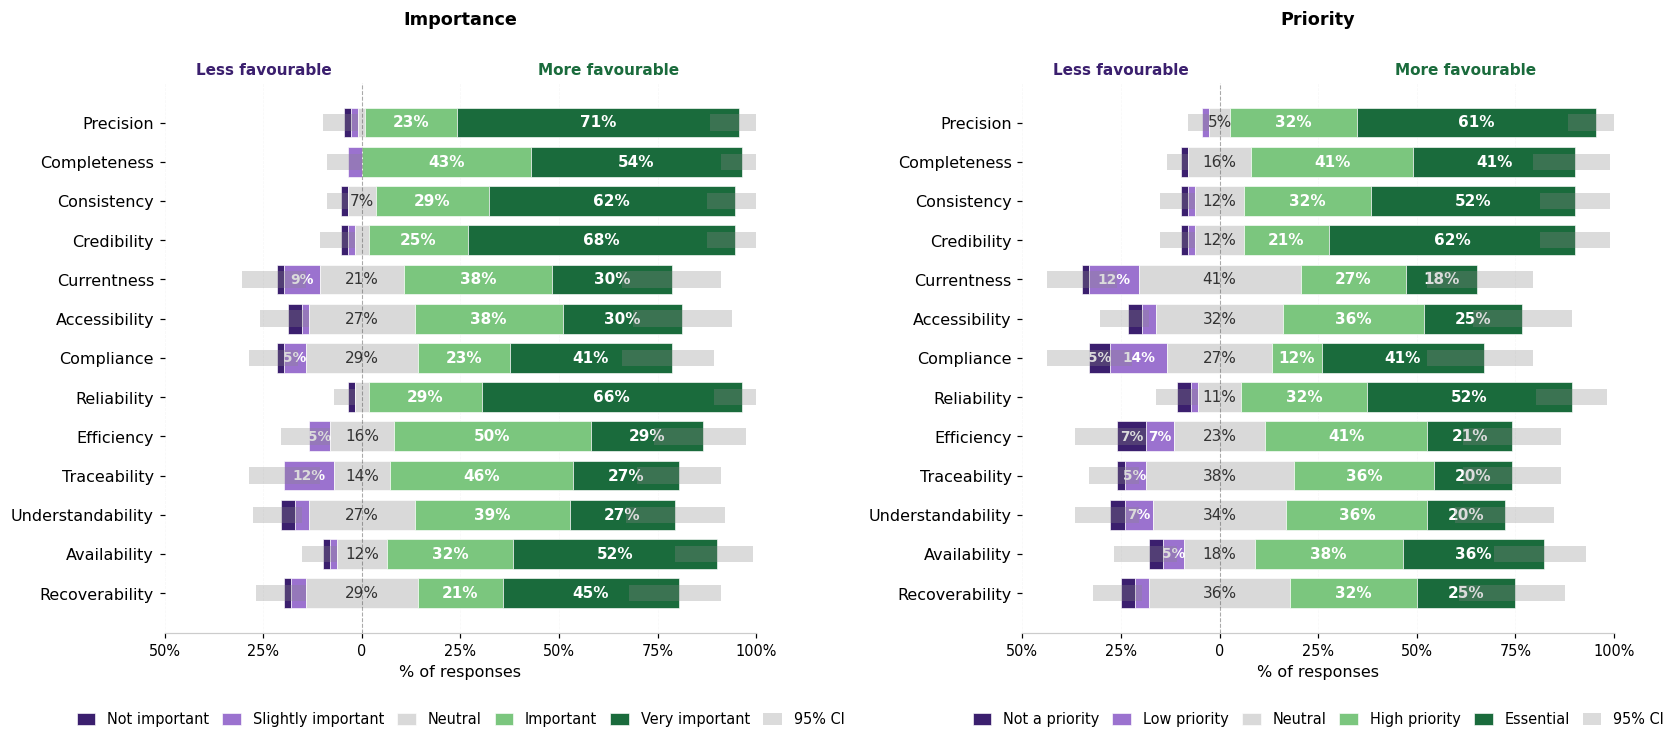

In [78]:
_imp_ci = _bootstrap_ci(
    imp_long, "characteristic", "importance",
    list(U.CHARACTERISTICS_PT.keys()),
    top_levels=[4, 5], bottom_levels=[1, 2]
)
_pri_ci = _bootstrap_ci(
    pri_long, "characteristic", "priority",
    list(U.CHARACTERISTICS_PT.keys()),
    top_levels=[4, 5], bottom_levels=[1, 2]
)

fig, (ax_imp, ax_pri) = plt.subplots(1, 2, figsize=(17.0, 6.5), gridspec_kw={"wspace": 0.45})

diverging_stacked(
    imp_long,
    item_col="characteristic",
    value_col="importance",
    item_labels=U.CHARACTERISTICS_PT,
    level_labels=["Not important", "Slightly important", "Neutral", "Important", "Very important"],
    ci_df=_imp_ci,
    ax=ax_imp,
    title="Importance",
)

diverging_stacked(
    pri_long,
    item_col="characteristic",
    value_col="priority",
    item_labels=U.CHARACTERISTICS_PT,
    level_labels=["Not a priority", "Low priority", "Neutral", "High priority", "Essential"],
    ci_df=_pri_ci,
    ax=ax_pri,
    title="Priority",
)

fig.tight_layout()
U.save_fig(fig, "importance_priority_diverging")
plt.show()

In [79]:
from IPython.display import display

_items = list(U.CHARACTERISTICS_PT.keys())

_imp_counts = (
    imp_long.groupby("characteristic")["importance"]
    .value_counts().unstack(fill_value=0)
    .reindex(index=_items, columns=range(1, 6), fill_value=0)
)
_imp_counts.columns = ["Not important", "Slightly important", "Neutral", "Important", "Very important"]
_imp_counts.index = [U.CHARACTERISTICS_PT[k] for k in _items]

_pri_counts = (
    pri_long.groupby("characteristic")["priority"]
    .value_counts().unstack(fill_value=0)
    .reindex(index=_items, columns=range(1, 6), fill_value=0)
)
_pri_counts.columns = ["Not a priority", "Low priority", "Neutral", "High priority", "Essential"]
_pri_counts.index = [U.CHARACTERISTICS_PT[k] for k in _items]

print("Importance (Q11) — absolute counts per Likert level")
display(_imp_counts)
print()
print("Priority (Q13) — absolute counts per Likert level")
display(_pri_counts)

Importance (Q11) — absolute counts per Likert level


,Not important,Slightly important,Neutral,Important,Very important
Precision,1,1,1,13,40
Completeness,0,2,0,24,30
Consistency,1,0,4,16,35
Credibility,1,1,2,14,38
Currentness,1,5,12,21,17
Accessibility,2,1,15,21,17
Compliance,1,3,16,13,23
Reliability,1,0,2,16,37
Efficiency,0,3,9,28,16
Traceability,0,7,8,26,15



Priority (Q13) — absolute counts per Likert level


,Not a priority,Low priority,Neutral,High priority,Essential
Precision,0,1,3,18,34
Completeness,1,0,9,23,23
Consistency,1,1,7,18,29
Credibility,1,1,7,12,35
Currentness,1,7,23,15,10
Accessibility,2,2,18,20,14
Compliance,3,8,15,7,23
Reliability,2,1,6,18,29
Efficiency,4,4,13,23,12
Traceability,1,3,21,20,11


## Q21 — Main Challenges

 # Inferencial tests


## 5. Paired Wilcoxon Signed-Rank — Importance vs Priority

Within-subject: for each characteristic, tests whether respondents assign different scores in Q11 (importance) and Q13 (priority). Formalizes the descriptive gap from Section 6 of notebook 02.

- Effect size: matched-pairs rank-biserial *r* (Kerby 2014); |r| < 0.1 negligible, < 0.3 small, < 0.5 medium, ≥ 0.5 large.
- Holm–Bonferroni within the family of the 13 characteristics.
-  ⇒ importance typically above priority (i.e., there is a gap).


In [80]:
rows = []
for col_imp, col_pri in zip(U.IMP_COLS, U.PRI_COLS):
    char = col_imp.split("_", 1)[1]
    res = U.wilcoxon_paired(df[col_imp], df[col_pri])
    rows.append({"characteristic": char,
                 "med_imp": float(df[col_imp].median()),
                 "med_pri": float(df[col_pri].median()),
                 **res})
paired = pd.DataFrame(rows)

valid = paired["p"].notna()
if valid.sum():
    reject, p_adj, _, _ = multipletests(paired.loc[valid, "p"], method="holm")
    paired["p_holm"] = float("nan")
    paired.loc[valid, "p_holm"] = p_adj
    paired["sig_holm"] = False
    paired.loc[valid, "sig_holm"] = reject
else:
    paired["p_holm"] = float("nan")
    paired["sig_holm"] = False
paired["sig_raw"] = paired["p"] < 0.05

paired_disp = paired[["characteristic", "n", "med_imp", "med_pri", "med_diff",
                       "r_rb", "magnitude", "W", "p", "p_holm", "sig_holm"]]
print(f"Significant paired (raw p<0.05): {paired['sig_raw'].sum()}")
print(f"Significant paired after Holm:   {paired['sig_holm'].sum()}")

Significant paired (raw p<0.05): 9
Significant paired after Holm:   4


In [81]:
out_path = U.DATA_PROC / "tables" / "wilcoxon_imp_vs_pri.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
paired_disp.to_csv(out_path, index=False)
print(f"-> {out_path.relative_to(U.ROOT)}")

sig_path = U.DATA_PROC / "tables" / "wilcoxon_imp_vs_pri_holm_sig.csv"
paired_disp.loc[paired_disp["sig_holm"] == True].to_csv(sig_path, index=False)
print(f"-> {sig_path.relative_to(U.ROOT)}")

U.save_latex(
    paired_disp,
    "wilcoxon_imp_vs_pri",
    caption="Paired Wilcoxon signed-rank tests: Importance vs. Priority (Q11 vs. Q13). "
            "Effect size $r$ via matched-pairs rank-biserial; Holm--Bonferroni correction across 13 characteristics.",
    label="tab:wilcoxon-imp-pri",
)
print("[saved] tables/wilcoxon_imp_vs_pri.tex")

U.save_latex(
    paired_disp.loc[paired_disp["sig_holm"] == True].reset_index(drop=True),
    "wilcoxon_imp_vs_pri_holm_sig",
    caption="Characteristics with statistically significant Importance--Priority gap after Holm--Bonferroni correction ($\alpha=0.05$).",
    label="tab:wilcoxon-holm-sig",
)
print("[saved] tables/wilcoxon_imp_vs_pri_holm_sig.tex")

-> data\processed\tables\wilcoxon_imp_vs_pri.csv
-> data\processed\tables\wilcoxon_imp_vs_pri_holm_sig.csv
[saved] tables/wilcoxon_imp_vs_pri.tex
[saved] tables/wilcoxon_imp_vs_pri_holm_sig.tex


dont pass

In [82]:
display(
    paired_disp.loc[lambda x: x["sig_holm"] == False]
    .sort_values("r_rb", key=abs, ascending=False)
    .reset_index(drop=True)
)

,characteristic,n,med_imp,med_pri,med_diff,r_rb,magnitude,W,p,p_holm,sig_holm
0,reliability,56,5.0,5.0,0.0,0.684211,large,30.0,0.005991,0.053917,False
1,compliance,56,4.0,4.0,0.0,0.672515,large,28.0,0.008625,0.062683,False
2,consistency,56,5.0,5.0,0.0,0.581699,large,32.0,0.021760,0.130560,False
3,recoverability,56,4.0,4.0,0.0,0.555556,large,84.0,0.007835,0.062683,False
4,credibility,56,5.0,5.0,0.0,0.476190,medium,27.5,0.100637,0.301911,False
5,traceability,56,4.0,4.0,0.0,0.399015,medium,122.0,0.040463,0.202314,False
6,understandability,56,4.0,4.0,0.0,0.391534,medium,115.0,0.056754,0.227015,False
7,accessibility,56,4.0,4.0,0.0,0.308300,medium,87.5,0.183396,0.366791,False
8,precision,56,5.0,5.0,0.0,0.291667,small,42.5,0.281799,0.366791,False


pass

In [83]:
display(
    paired_disp.loc[lambda x: x["sig_holm"] == True]
    .sort_values("r_rb", key=abs, ascending=False)
    .reset_index(drop=True)
)

,characteristic,n,med_imp,med_pri,med_diff,r_rb,magnitude,W,p,p_holm,sig_holm
0,availability,56,5.0,4.0,0.0,0.771429,large,24.0,0.001426,0.017110,True
1,completeness,56,5.0,4.0,0.0,0.653680,large,40.0,0.003921,0.039211,True
2,efficiency,56,4.0,4.0,0.0,0.649231,large,57.0,0.003099,0.034085,True
3,currentness,56,4.0,3.0,0.0,0.615530,large,101.5,0.000914,0.011887,True


## Spearman Rank Correlation — Importance × Priority (H1)

We formulate one hypothesis covering the relationship between the two perception dimensions assessed in this study:

- **H1**: Importance and priority are strongly correlated per characteristic (|ρ| ≥ 0.60, p < 0.05)
- **H1₀**: No strong correlation between importance and priority

We first applied the Shapiro–Wilk test (Shapiro & Wilk, 1965), which indicated non-normal distributions. Therefore, we used Spearman's rank correlation coefficient (Wohlin et al., 2012) with a 95% confidence level (p < 0.05). Color coding follows Salkind (2012): very strong |ρ| ≥ 0.80, strong 0.60–0.79, moderate 0.40–0.59, weak 0.20–0.39.


In [84]:
from scipy.stats import shapiro, spearmanr
rng = np.random.default_rng(42)

# Step 1 — Shapiro-Wilk: confirm non-normality to justify Spearman
sw_results = []
for col_imp, col_pri in zip(U.IMP_COLS, U.PRI_COLS):
    char = col_imp.split("_", 1)[1]
    _, p_imp = shapiro(df[col_imp].dropna())
    _, p_pri = shapiro(df[col_pri].dropna())
    sw_results.append({
        "characteristic": char,
        "p_imp": p_imp, "normal_imp": p_imp >= 0.05,
        "p_pri": p_pri, "normal_pri": p_pri >= 0.05
    })

sw_df = pd.DataFrame(sw_results)
n_nn_imp = (~sw_df["normal_imp"]).sum()
n_nn_pri = (~sw_df["normal_pri"]).sum()

print(f"(IMP) Shapiro-Wilk: {n_nn_imp}/13 importance distributions non-normal (p<0.05)")
print(f"(PRI) Shapiro-Wilk: {n_nn_pri}/13 priority distributions non-normal (p<0.05)")
print("→ Non-normal distributions justify Spearman's rank correlation.\n")

(IMP) Shapiro-Wilk: 13/13 importance distributions non-normal (p<0.05)
(PRI) Shapiro-Wilk: 13/13 priority distributions non-normal (p<0.05)
→ Non-normal distributions justify Spearman's rank correlation.



In [85]:
# Step 2 — Spearman ρ per characteristic
def _salkind_strength(rho: float) -> str:
    r = abs(rho)
    if r >= 0.80:   return "Very Strong"
    elif r >= 0.60: return "Strong"
    elif r >= 0.40: return "Moderate"
    elif r >= 0.20: return "Weak"
    return "Very Weak"


spearman_rows = []
for col_imp, col_pri in zip(U.IMP_COLS, U.PRI_COLS):
    char = col_imp.split("_", 1)[1]
    mask = df[col_imp].notna() & df[col_pri].notna()
    rho, p = spearmanr(df.loc[mask, col_imp], df.loc[mask, col_pri])

    spearman_rows.append({
        "characteristic": char,
        "n": int(mask.sum()),
        "rho": float(rho),
        "p": float(p),
        "sig": float(p) < 0.05,
        "strength": _salkind_strength(float(rho)),
    })

spearman_df = pd.DataFrame(spearman_rows)

n_sig = spearman_df["sig"].sum()
print(f"H1 — significant (p<0.05): {n_sig}/13 characteristics")


# --- Build display table (igual ao styled_table) ---
display_df = spearman_df.copy()
display_df.index = display_df["characteristic"].map(U.CHARACTERISTICS_EN)
display_df = display_df[["rho"]].rename(columns={"rho": "Imp × Pri (H1)"})


# --- Estilo visual no notebook (mantido) ---
def _salkind_color(val):
    if not isinstance(val, (int, float)) or pd.isna(val):
        return ""
    r = abs(val)
    if r >= 0.80:   return "background-color: #1a6b3c; color: white"
    elif r >= 0.60: return "background-color: #7bc67e"
    elif r >= 0.40: return "background-color: #ffe066"
    elif r >= 0.20: return "background-color: #e57373; color: white"
    return ""


styled_table = (
    display_df.style
    .map(_salkind_color)
    .format("{:.3f}")
    .set_caption(
        "Spearman ρ between Importance (Q11) and Priority (Q13) per characteristic. "
        "Color: dark green ≥ 0.80 (very strong), light green ≥ 0.60 (strong), "
        "yellow ≥ 0.40 (moderate), red ≥ 0.20 (weak) — Salkind (2012)."
    )
)

display(styled_table)


# --- CSV export ---
spearman_out = spearman_df[["characteristic", "n", "rho", "p", "sig", "strength"]]
spearman_out.to_csv(TABLES / "spearman_imp_vs_pri.csv", index=False)
print(f"-> tables/spearman_imp_vs_pri.csv")


# --- Função para colorir no LaTeX ---
def _latex_salkind_color(val):
    if not isinstance(val, (int, float)) or pd.isna(val):
        return ""

    r = abs(val)

    if r >= 0.80:
        return f"\\cellcolor{{green!70!black}}\\textcolor{{white}}{{{val:.3f}}}"
    elif r >= 0.60:
        return f"\\cellcolor{{green!30}}{{{val:.3f}}}"
    elif r >= 0.40:
        return f"\\cellcolor{{yellow!60}}{{{val:.3f}}}"
    elif r >= 0.20:
        return f"\\cellcolor{{red!60}}\\textcolor{{white}}{{{val:.3f}}}"
    else:
        return f"{val:.3f}"


# --- Monta versão LaTeX ---
latex_df = display_df.copy()
latex_df["Imp × Pri (H1)"] = latex_df["Imp × Pri (H1)"].apply(_latex_salkind_color)


latex_str = latex_df.to_latex(
    escape=False,
    column_format="l c",
    caption=(
        "Spearman $\\rho$ between Importance (Q11) and Priority (Q13). "
        "Very strong ($0.80 \\leq |\\rho| \\leq 1.00$) in dark green, "
        "strong ($0.60 \\leq |\\rho| < 0.80$) in light green, "
        "moderate ($0.40 \\leq |\\rho| < 0.60$) in yellow, and "
        "weak ($0.20 \\leq |\\rho| < 0.40$) in red."
    ),
    label="tab:spearman-imp-pri"
)


with open(TABLES / "spearman_imp_vs_pri_colors.tex", "w") as f:
    f.write(latex_str)

print("[saved] tables/spearman_imp_vs_pri_colors.tex")

H1 — significant (p<0.05): 13/13 characteristics


,Imp × Pri (H1)
characteristic,
Precision,0.637
Completeness,0.585
Consistency,0.589
Credibility,0.573
Currentness,0.714
Accessibility,0.542
Compliance,0.832
Reliability,0.544
Efficiency,0.526


-> tables/spearman_imp_vs_pri.csv
[saved] tables/spearman_imp_vs_pri_colors.tex


raw form

In [86]:
# Build display table mimicking the reference paper (one column per hypothesis pair)
display_df = spearman_df.copy()
display_df.index = display_df["characteristic"].map(U.CHARACTERISTICS_EN)
display_df = display_df[["rho"]].rename(columns={"rho": "Imp × Pri (H1)"})

def _salkind_color(val):
    if not isinstance(val, (int, float)) or pd.isna(val):
        return ""
    r = abs(val)
    if r >= 0.80:   return "background-color: #1a6b3c; color: white"
    elif r >= 0.60: return "background-color: #7bc67e"
    elif r >= 0.40: return "background-color: #ffe066"
    elif r >= 0.20: return "background-color: #e57373; color: white"
    return ""

styled_table = (
    display_df.style
    .map(_salkind_color)
    .format("{:.3f}")
    .set_caption(
        "Spearman ρ between Importance (Q11) and Priority (Q13) per characteristic. "
        "Color: dark green ≥ 0.80 (very strong), light green ≥ 0.60 (strong), "
        "yellow ≥ 0.40 (moderate), red ≥ 0.20 (weak) — Salkind (2012)."
    )
    .set_table_styles([
        {"selector": "th.col_heading", "props": [("text-align", "center"), ("font-weight", "bold")]},
        {"selector": "td", "props": [("text-align", "center"), ("padding", "4px 16px")]},
        {"selector": "th.row_heading", "props": [("text-align", "left"), ("padding", "4px 12px")]},
    ])
)

display(styled_table)

# Save CSV + LaTeX
spearman_out = spearman_df[["characteristic", "rho", "strength", "p"]]
# spearman_out = spearman_df[["characteristic", "n", "rho", "p", "sig", "strength"]]
spearman_out.to_csv(TABLES / "spearman_imp_vs_pri.csv", index=False)
print(f"-> tables/spearman_imp_vs_pri.csv")

U.save_latex(
    spearman_out,
    "spearman_imp_vs_pri",
    caption=(
        "Spearman's rank correlation coefficient ($\\rho$) between Importance (Q11) "
        "and Priority (Q13) for each data quality characteristic. "
        "Confidence level: 95\\% ($p < 0.05$). "
        "Correlation strength classification follows Salkind (2012)."
    ),
    label="tab:spearman-imp-pri",
)
print("[saved] tables/spearman_imp_vs_pri.tex")


,Imp × Pri (H1)
characteristic,
Precision,0.637
Completeness,0.585
Consistency,0.589
Credibility,0.573
Currentness,0.714
Accessibility,0.542
Compliance,0.832
Reliability,0.544
Efficiency,0.526


-> tables/spearman_imp_vs_pri.csv
[saved] tables/spearman_imp_vs_pri.tex


## 6. Friedman + Nemenyi — Global Ranking of the 13 Characteristics

Within-subject: each respondent ranks the 13 characteristics. Friedman tests whether there are systematic rank differences; Nemenyi is the standard non-parametric post-hoc for treatment pairs after Friedman (Demšar 2006).

Applied separately to Q11 (importance) and Q13 (priority). Rows with any NA are dropped (within-subject requires all treatments per subject).


In [87]:
import scikit_posthocs as sp

def friedman_block(cols: list[str], dim_name: str) -> dict:
    block = df[cols].dropna()
    n_subj = len(block)
    if n_subj < 5:
        return {"dim": dim_name, "n": n_subj, "chi2": float("nan"),
                "p": float("nan"), "df": len(cols) - 1, "nemenyi": None,
                "mean_ranks": None}
    chi2, p = stats.friedmanchisquare(*[block[c].values for c in cols])
    # Nemenyi post-hoc: K×K p-value matrix. Accepts wide form: rows=subjects, cols=treatments.
    nemenyi = sp.posthoc_nemenyi_friedman(block.to_numpy())
    nemenyi.index = [c.split("_", 1)[1] for c in cols]
    nemenyi.columns = nemenyi.index
    # Mean ranks (Friedman ranks within each subject, then averaged across subjects)
    ranks = block.rank(axis=1, method="average")
    mean_ranks = ranks.mean().sort_values()
    mean_ranks.index = [c.split("_", 1)[1] for c in cols]
    return {"dim": dim_name, "n": n_subj, "chi2": float(chi2), "p": float(p),
            "df": len(cols) - 1, "nemenyi": nemenyi, "mean_ranks": mean_ranks}

friedman_imp = friedman_block(U.IMP_COLS, "importance")
friedman_pri = friedman_block(U.PRI_COLS, "priority")

for r in (friedman_imp, friedman_pri):
    print(f"=== Friedman — {r['dim']} (complete N = {r['n']}) ===")
    print(f"  chi² = {r['chi2']:.2f}  df = {r['df']}  p = {r['p']:.6f}")

for r, name in [(friedman_imp, "imp"), (friedman_pri, "pri")]:
    if r["nemenyi"] is not None:
        r["nemenyi"].to_csv(TABLES / f"nemenyi_{name}.csv")
        r["mean_ranks"].to_csv(TABLES / f"friedman_ranks_{name}.csv", header=["mean_rank"])
        print(f"-> tables/nemenyi_{name}.csv, tables/friedman_ranks_{name}.csv")

=== Friedman — importance (complete N = 56) ===
  chi² = 116.19  df = 12  p = 0.000000
=== Friedman — priority (complete N = 56) ===
  chi² = 126.01  df = 12  p = 0.000000
-> tables/nemenyi_imp.csv, tables/friedman_ranks_imp.csv
-> tables/nemenyi_pri.csv, tables/friedman_ranks_pri.csv


In [88]:
_ranks_df = pd.DataFrame({
    "importance_rank": friedman_imp["mean_ranks"],
    "priority_rank":   friedman_pri["mean_ranks"],
}).sort_values("importance_rank", ascending=False)
#display(_ranks_df)

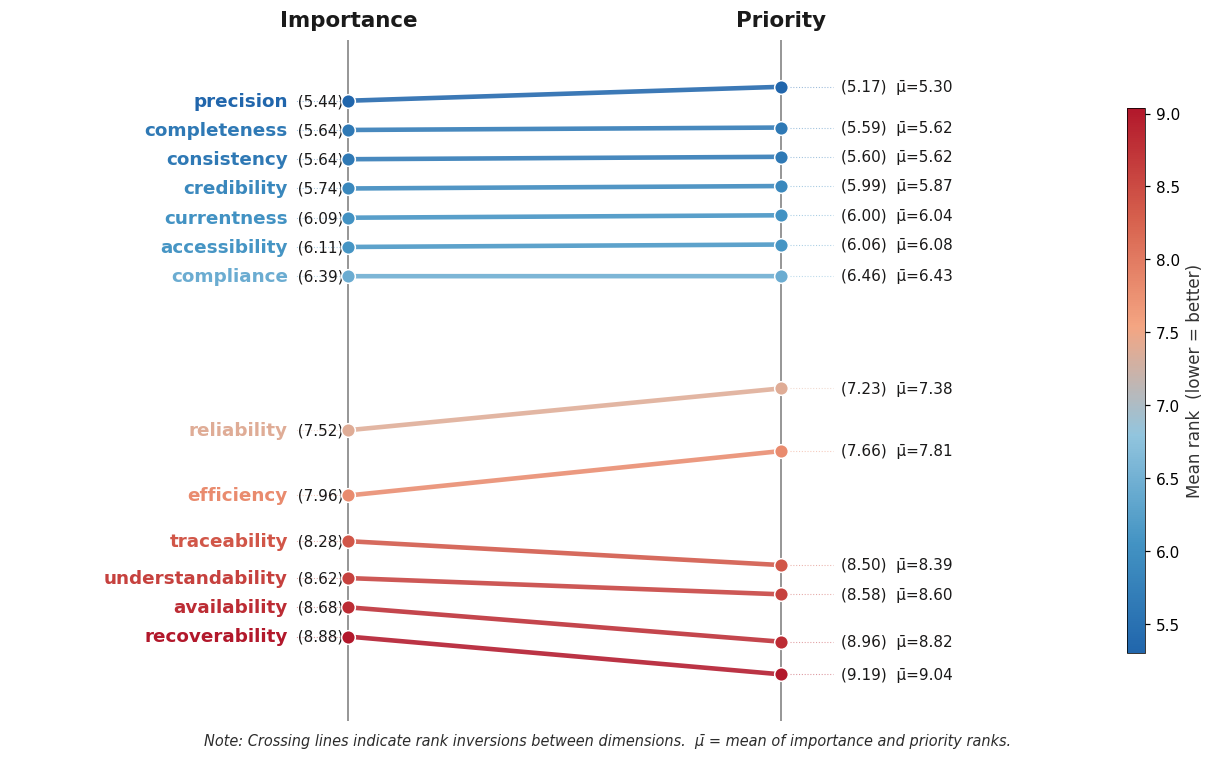

In [89]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def plot_slope_ranks(ranks_df: pd.DataFrame, figsize=(11, 7)) -> plt.Figure:
    df = ranks_df.copy()
    if "mean_rank" not in df.columns:
        df["mean_rank"] = df[["importance_rank", "priority_rank"]].mean(axis=1)
    df = df.sort_values("mean_rank", ascending=False)

    all_ranks = pd.concat([df["importance_rank"], df["priority_rank"]])
    vmin, vmax = all_ranks.min(), all_ranks.max()

    cmap = mcolors.LinearSegmentedColormap.from_list(
        "pub", ["#2166AC", "#4393C3", "#92C5DE", "#F4A582", "#D6604D", "#B2182B"]
    )
    norm = mcolors.Normalize(vmin=df["mean_rank"].min(), vmax=df["mean_rank"].max())

    def spread_positions(values, min_gap=0.20):
        sorted_idx = np.argsort(values)
        pos = np.array(values, dtype=float)
        for _ in range(500):
            changed = False
            for i in range(len(sorted_idx) - 1):
                a, b = sorted_idx[i], sorted_idx[i + 1]
                if pos[b] - pos[a] < min_gap:
                    mid = (pos[a] + pos[b]) / 2
                    pos[a] = mid - min_gap / 2
                    pos[b] = mid + min_gap / 2
                    changed = True
            if not changed:
                break
        return pos

    y_imp_orig   = df["importance_rank"].values
    y_pri_orig   = df["priority_rank"].values
    y_imp_spread = spread_positions(y_imp_orig)
    y_pri_spread = spread_positions(y_pri_orig)

    y_lo  = min(y_imp_spread.min(), y_pri_spread.min())
    y_hi  = max(y_imp_spread.max(), y_pri_spread.max())
    y_pad = (y_hi - y_lo) * 0.08

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    x_left, x_right = 0.0, 1.0
    ax.set_xlim(-0.78, 1.78)
    ax.set_ylim(y_hi + y_pad, y_lo - y_pad)

    for x in (x_left, x_right):
        ax.axvline(x, color="#797979", linewidth=1.0, zorder=0)

    for i, (_, row) in enumerate(df.iterrows()):
        color = cmap(norm(row["mean_rank"]))
        yi_s  = y_imp_spread[i]
        yp_s  = y_pri_spread[i]
        yi_o  = y_imp_orig[i]
        yp_o  = y_pri_orig[i]
        name  = row.name
        mean  = row["mean_rank"]

        # Linha principal
        ax.plot([x_left, x_right], [yi_s, yp_s],
                color=color, linewidth=3.0, alpha=0.88,
                solid_capstyle="round", zorder=3)

        # Pontos
        ax.scatter([x_left, x_right], [yi_s, yp_s],
                   color=color, s=80, zorder=5,
                   edgecolors="white", linewidths=1.0)

        # Guias tracejadas
        ax.plot([x_left - 0.02, x_left - 0.12], [yi_s, yi_s],
                color=color, linewidth=0.7, linestyle=":", alpha=0.45)
        ax.plot([x_right + 0.02, x_right + 0.12], [yp_s, yp_s],
                color=color, linewidth=0.7, linestyle=":", alpha=0.45)

        # ── Label esquerda: "Nome  (5.40)" numa linha só ──────────
        ax.text(x_left - 0.14, yi_s,
                f"{name}",
                ha="right", va="center", fontsize=12,
                color=color, fontweight="bold")
        ax.text(x_left - 0.14, yi_s,
                f"  ({yi_o:.2f})",          # espaço + valor colado à direita do nome
                ha="left",  va="center", fontsize=10,
                color="#1A1919")

        # ── Label direita: "(7.10)  μ̄ = 6.55" numa linha só ──────
        ax.text(x_right + 0.14, yp_s,
                f"({yp_o:.2f})  μ̄={mean:.2f}",
                ha="left", va="center", fontsize=10,
                color="#1A1919")

    gap = y_pad * 0.45
    ax.text(x_left,  y_lo - y_pad - gap*1.4, "Importance",
        ha="center", va="top", fontsize=14, color="#1a1a1a", fontweight="bold")
    ax.text(x_right, y_lo - y_pad - gap*1.4, "Priority",
        ha="center", va="top", fontsize=14, color="#1a1a1a", fontweight="bold")

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.016, pad=0.008, aspect=30)
    cbar.set_label("Mean rank  (lower = better)", fontsize=11, color="#333333")
    cbar.ax.tick_params(labelsize=10)
    cbar.outline.set_linewidth(0.5)

    ax.axis("off")

    fig.text(
        0.5, 0.01,
        "Note: Crossing lines indicate rank inversions between dimensions.  "
        "μ̄ = mean of importance and priority ranks.",
        ha="center", fontsize=9.5, color="#2C2C2C", style="italic"
    )

    fig.tight_layout(rect=[0, 0.03, 1, 0.97], pad=0.6)
    return fig


fig = plot_slope_ranks(_ranks_df)
U.save_fig(fig, "friedman_mean_ranks")
plt.show()

In [90]:
# Significant Nemenyi pairs (p < 0.05) by dimension
def list_significant_pairs(result, alpha: float = 0.05) -> pd.DataFrame:
    if result["nemenyi"] is None:
        return pd.DataFrame()
    nem = result["nemenyi"]
    rows = []
    chars = list(nem.index)
    for i, a in enumerate(chars):
        for b in chars[i + 1:]:
            p = float(nem.loc[a, b])
            if p < alpha:
                rows.append({"dim": result["dim"], "a": a, "b": b,
                             "rank_a": float(result["mean_ranks"][a]),
                             "rank_b": float(result["mean_ranks"][b]),
                             "p": p})
    return pd.DataFrame(rows).sort_values("p")

sig_imp = list_significant_pairs(friedman_imp)
sig_pri = list_significant_pairs(friedman_pri)

print(f"Nemenyi significant pairs (p<0.05) — importance: {len(sig_imp)}")
print(f"Nemenyi significant pairs (p<0.05) — priority:   {len(sig_pri)}")

Nemenyi significant pairs (p<0.05) — importance: 24
Nemenyi significant pairs (p<0.05) — priority:   26


## 11. Aggregated skills — % "Above average/Very high"

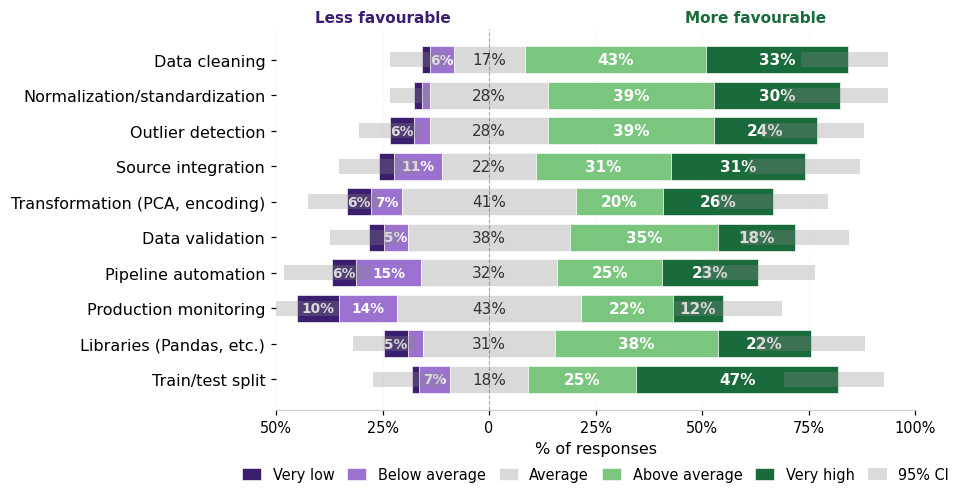

In [91]:
skills_renamed = skills_long.copy()
_skill_items = list(U.SKILL_LABELS_PT.keys())

_skill_ci = _bootstrap_ci(
    skills_renamed.dropna(),
    "activity",
    "skill",
    _skill_items,
    top_levels=[4, 5],
    bottom_levels=[1, 2],
)

fig = diverging_stacked(
    skills_renamed.dropna(),
    item_col="activity",
    value_col="skill",
    item_labels=U.SKILL_LABELS_PT,
    level_labels=["Very low", "Below average", "Average", "Above average", "Very high"],
    figsize=(7.5, 4.5),
    ci_df=_skill_ci,
)

U.save_fig(fig, "skills_diverging")
plt.show()

In [92]:
from IPython.display import display

_skill_items = list(U.SKILL_LABELS_PT.keys())

_skill_counts = (
    skills_renamed.dropna().groupby("activity")["skill"]
    .value_counts().unstack(fill_value=0)
    .reindex(index=_skill_items, columns=range(1, 6), fill_value=0)
)
_skill_counts.columns = ["Very low", "Below average", "Average", "Above average", "Very high"]
_skill_counts.index = [U.SKILL_LABELS_PT[k] for k in _skill_items]

print("Skills (Q8) — absolute counts per Likert level")
display(_skill_counts)

Skills (Q8) — absolute counts per Likert level


,Very low,Below average,Average,Above average,Very high
Data cleaning,1,3,9,23,18
Normalization/standardization,1,1,15,21,16
Outlier detection,3,2,15,21,13
Source integration,2,6,12,17,17
"Transformation (PCA, encoding)",3,4,22,11,14
Data validation,2,3,21,19,10
Pipeline automation,3,8,17,13,12
Production monitoring,5,7,22,11,6
"Libraries (Pandas, etc.)",3,2,17,21,12
Train/test split,1,4,10,14,26


In [93]:
from IPython.display import display as _display
print("── Importance ──")
_display(sig_imp.reset_index(drop=True))
print("── Priority ──")
_display(sig_pri.reset_index(drop=True))

── Importance ──


,dim,a,b,rank_a,rank_b,p
0,importance,precision,understandability,5.437500,8.625000,0.000210
1,importance,precision,currentness,5.437500,6.089286,0.000767
2,importance,precision,accessibility,5.437500,6.107143,0.000767
3,importance,reliability,understandability,7.517857,8.625000,0.000767
4,importance,credibility,understandability,5.741071,8.625000,0.001061
5,importance,precision,traceability,5.437500,8.276786,0.001383
6,importance,currentness,reliability,6.089286,7.517857,0.002568
7,importance,accessibility,reliability,6.107143,7.517857,0.002568
8,importance,credibility,currentness,5.741071,6.089286,0.003467
9,importance,credibility,accessibility,5.741071,6.107143,0.003467


── Priority ──


,dim,a,b,rank_a,rank_b,p
0,priority,precision,currentness,5.169643,6.000000,0.000004
1,priority,credibility,currentness,5.991071,6.000000,0.000019
2,priority,precision,understandability,5.169643,8.580357,0.000076
3,priority,precision,traceability,5.169643,8.500000,0.000081
4,priority,currentness,reliability,6.000000,7.232143,0.000265
5,priority,credibility,understandability,5.991071,8.580357,0.000333
6,priority,credibility,traceability,5.991071,8.500000,0.000352
7,priority,consistency,currentness,5.598214,6.000000,0.000441
8,priority,precision,accessibility,5.169643,6.062500,0.001005
9,priority,precision,recoverability,5.169643,9.187500,0.001061


## 6. Q16 — anomaly as a meta-finding

30 out of 32 PT responses identical. The 2 divergent ones (P04 and P23) are semantically *wrong* alternatives: P04 says versioning *eliminates* documentation, P23 says it increases data *without* checking consistency. The pattern suggests a poorly designed instrument: a tendentiously correct option set as default + distractors rarely chosen. Reported in the paper as an instrument-validity finding, not as substantive evidence.

In [94]:
q16 = df["versioning_norm"].value_counts(dropna=False)
print("=== Q16 response distribution ===")
for txt, n in q16.items():
    short = (txt[:80] + "...") if isinstance(txt, str) and len(txt) > 80 else txt
    print(f"  {n}× {short!r}")
print(f"\nDominant response proportion: {q16.iloc[0]/len(df)*100:.1f}% (n={q16.iloc[0]}/{len(df)})")

# Binomial test: is the dominant response compatible with uniform selection across 4 options?
# H0: dominant option has probability p_null = 1/4 (uniform draw)
# H1: probability > 1/4 (anomalous concentration)
from scipy.stats import binomtest
n_total = len(df)
k_dominant = int(q16.iloc[0])
n_options = 4  # Q16 has 4 options in the form
p_null = 1 / n_options
res = binomtest(k_dominant, n_total, p=p_null, alternative="greater")
ci = res.proportion_ci(confidence_level=0.95, method="wilson")
print()
print(f"=== Binomial test — Q16 ===")
print(f"H0: p_dominant = 1/{n_options} = {p_null:.3f} (uniform draw)")
print(f"Observed: {k_dominant}/{n_total} = {k_dominant/n_total:.3f}")
print(f"IC95% Wilson: [{ci.low:.3f}, {ci.high:.3f}]")
print(f"p-value (one-sided): {res.pvalue:.2e}")
print(f"-> Rejects H0 decisively: distribution incompatible with random selection.")
print(f"   Supports the pre-selected default-option hypothesis in Google Forms.")

=== Q16 response distribution ===
  51× 'ensures_consistency_traceability'
  3× 'eliminates_documentation_need'
  1× 'increases_data_quantity'
  1× 'no_experience'

Dominant response proportion: 91.1% (n=51/56)

=== Binomial test — Q16 ===
H0: p_dominant = 1/4 = 0.250 (uniform draw)
Observed: 51/56 = 0.911
IC95% Wilson: [0.828, 1.000]
p-value (one-sided): 1.85e-25
-> Rejects H0 decisively: distribution incompatible with random selection.
   Supports the pre-selected default-option hypothesis in Google Forms.
